# Homework
### Silvia Parente 
due May 11th

## Spectral comparison of abundances

I modeled a planetary nebula using cloudy. I compared a simulation run with planetary nebula abundances against one using standard solar abundances, noticed several differences. 
The planetary nebula spectrum shows stronger emission lines, expected since these environments are enriched with heavier elements (carbon, nitrogen, oxygen) produced during the dying star's evolution. the planetary nebula model also includs a big thermal emission bump peaking around 30 microns. absent in the solar abundance model because the planetary nebula environment contains dust grains that are heated by the central star, causing them to radiate strongly in the infrared.

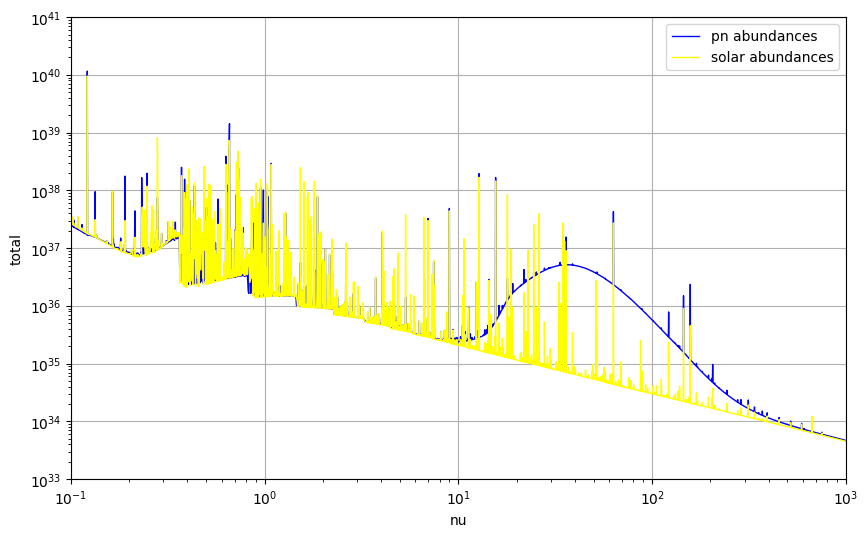

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cols = [
    'nu', 'incident', 'trans', 'DiffOut', 'net_trans', 
    'reflc', 'total', 'reflin', 'outlin', 'lineID', 'cont', 'nLine'
]

df = pd.read_csv(
    'pn.con', 
    sep=r'\s+', 
    names=cols, 
    comment='#', 
    on_bad_lines='skip',     
)

dfs = pd.read_csv(
    'solar.con', 
    sep=r'\s+', 
    names=cols, 
    comment='#', 
    on_bad_lines='skip',     
)


plt.figure(figsize=(10, 6))
plt.plot(df['nu'], df['total'], color='blue', label='pn abundances', linewidth=1, )
plt.plot(dfs['nu'], dfs['total'], color='yellow', label='solar abundances', linewidth=1)
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1, 1000)
plt.ylim(10e32, 10e40)
plt.grid()
plt.xlabel('nu')
plt.ylabel('total')
plt.legend()
plt.show()

## Thermal and ionization structure

I extracted data from the .ovr files to plot the internal thermal and ionization structures as a function of distance from the central star. the temperature profile shows how the gas kinetic temperature changes with depth. near the ionizing source the gas is very hot (over 10000 K) and as the radiation is absorbed outward the temperature lowers until it stops at 4000 K. In the ionization structure thee fraction of ionized hydrogen remains near 100 percent for a big distance outward. eventually at the edge of the highly ionized H II region the supply of ionizing photons finifhes and the ionization fraction drops as the remaining gas transitions to a neutral state.

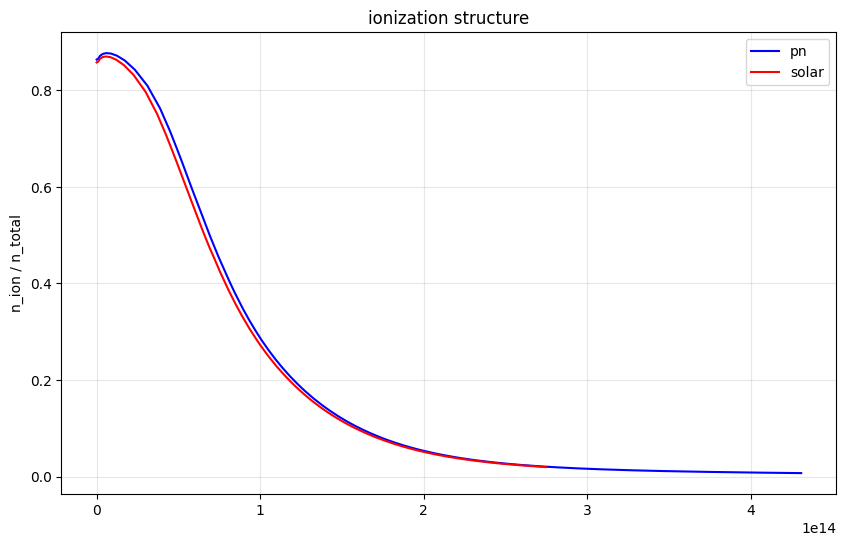

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

df_pn_ovr = pd.read_csv('pn.ovr', sep=r'\s+', comment='#')
df_solar_ovr = pd.read_csv('solar.ovr', sep=r'\s+', comment='#')

plt.figure(figsize=(10, 6))
plt.plot(df_pn_ovr.iloc[:, 0], df_pn_ovr.iloc[:, 7], label='pn', color='blue')
plt.plot(df_solar_ovr.iloc[:, 0], df_solar_ovr.iloc[:, 7], label='solar', color='red')
plt.title('ionization structure')
plt.ylabel('n_ion / n_total')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

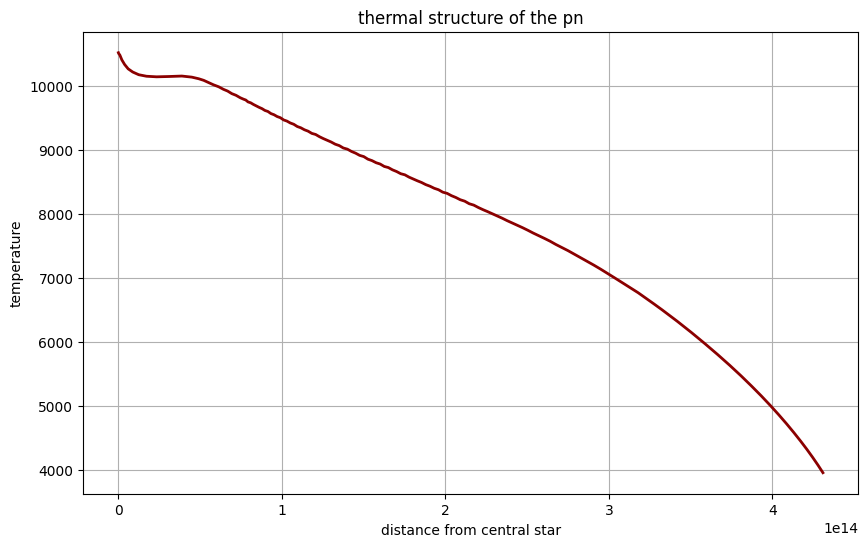

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

df_pn_ovr = pd.read_csv('pn.ovr', sep=r'\s+', comment='#')

plt.figure(figsize=(10, 6))
plt.plot(df_pn_ovr.iloc[:, 0], df_pn_ovr.iloc[:, 1], color='darkred', linewidth=2)

plt.xlabel('distance from central star')
plt.ylabel('temperature')
plt.title('thermal structure of the pn')
plt.grid()
plt.show()

## BLR grid

I generated a grid of models with hydrogen densities from $10^8$ to $10^{14}$ and ionizing fluxes from $10^{18}$ to $10^{24}$. in the high densiyies of the BLR the gas becomes optically thick leading to collisional excitation that push the emission ratios into different regimes. 

H-alpha in column 'h  1 6562.80A '
H-beta in column 'H  1 4861.32A '
169 converged grid points


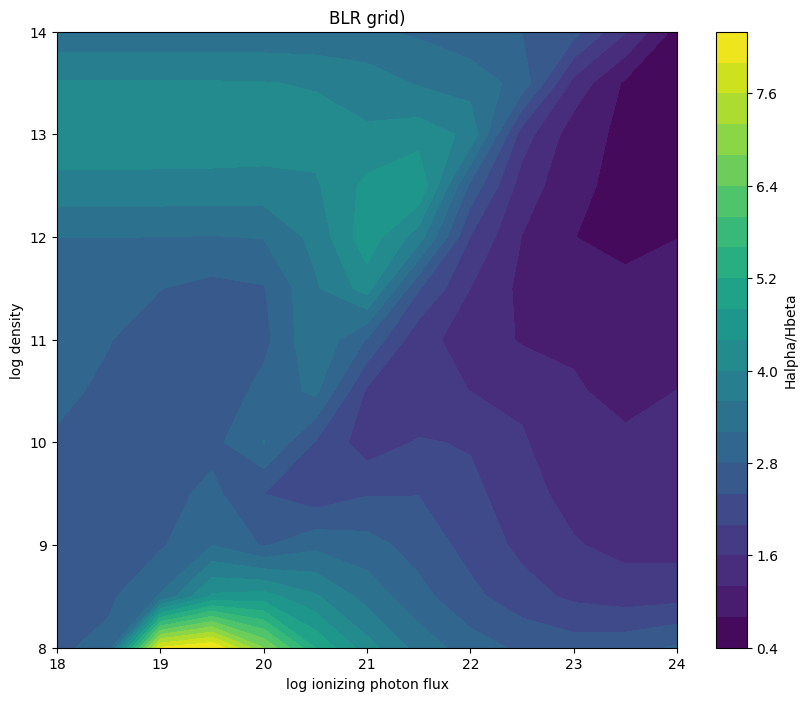

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

densities = np.arange(8.0, 14.5, 0.5)
luminosities = np.arange(18.0, 24.5, 0.5)

df = pd.read_csv('blr_grid.lin', sep='\t')

# column names for halpha and hbeta 
ha_col = next(col for col in df.columns if '6562' in col)
hb_col = next(col for col in df.columns if '4861' in col)

print(f"H-alpha in column '{ha_col}'")
print(f"H-beta in column '{hb_col}'")

# converged iterations one row before grid delimit
grid_delimit = df.iloc[:, 0].astype(str).str.contains('GRID_DELIMIT')
converged_indices = df[grid_delimit].index - 1
# last grid doesn't have delimiter
if not grid_delimit.iloc[-1]:
    converged_indices = converged_indices.append(pd.Index([df.index[-1]]))
# keep only converged rows
df_converged = df.loc[converged_indices]

flux_Ha = df_converged[ha_col].astype(float).values
flux_Hb = df_converged[hb_col].astype(float).values

print(f"{len(flux_Ha)} converged grid points")


ratio = flux_Ha / flux_Hb
ratio_matrix = ratio.reshape(len(densities), len(luminosities))

plt.figure(figsize=(10, 8))
X, Y = np.meshgrid(luminosities, densities)
contour = plt.contourf(X, Y, ratio_matrix, levels=20, cmap='viridis')
cbar = plt.colorbar(contour)
cbar.set_label('Halpha/Hbeta')
plt.xlabel('log ionizing photon flux')
plt.ylabel('log density')
plt.title('BLR grid)')
plt.show()

comment:
I did that LineList_BLR.dat to just select halpha and hbeta but I can see it did not work and had to locate 'by hand' the exact name of columns of halpha and hbeta. 
